# Spring 2026 CMSC320 Final Project: ⚛






Team Members:

Saisha Pitani: I worked on the final tutorial report creation including structuring and formatting. Additionally, I worked on the dataset curation and preprocessing section gathering and cleaning data.


Pari Gill


Alex Emmert: I worked on the exploratory data analysis section.


Christopher Liu

# **Part 1 - Introduction:**


Social media has become a major part of everyday life, influencing communication, entertainment, shopping habits, mental health, and lifestyle. Different platforms such as Instagram, TikTok, Facebook, and Twitter generate massive amounts of user activity data that can be analyzed to better understand human behavior. We analyzed the “Social Media User Analysis” dataset from Kaggle, which contains user profiles with demographic, behavioral, and lifestyle information in correlation to social media usage.

The main goal of this analysis is to explore how different factors such as age, gender, lifestyle habits, screen time, and engagement relate to social media behavior. We aim to answer questions such as:


Is there a relationship between engagement levels and lifestyle or health-related factors?

Can user behavior patterns help predict high engagement or heavy social media usage?

Answering these questions is important because social media affects both individuals and businesses in significant ways. Companies and marketers can use these insights to better understand user engagement and improve digital marketing strategies. Researchers and educators can study how online behavior connects to lifestyle habits and well-being.  By using data analysis and machine learning techniques, this project aims to uncover meaningful trends and provide insights into how individuals interact with social media in the  digital world.

# **Part 2: Data curation**




Source: The dataset used in this project is the “Social Media User Analysis” dataset available on Kaggle. The dataset contains over one million synthetic social media user records designed to simulate real-world user behavior across multiple platforms. Each entry includes demographic information, engagement, lifestyle factors, and usage patterns based on platforms. The dataset was created for educational and analytical purposes, making it useful for data science and machine learning projects without exposing sensitive user information.


Source Link: https://www.kaggle.com/datasets/rockyt07/social-media-user-analysis



Here are the features included within the dataset:



*   Age
*   Location

*   Gender

*   Social media platform
*   Daily Screen Time


*   Number of posts , comments, followers, likes

*   Lifestyle habits
*   Engagement metrics













Importing and Condensing: The dataset originally had 1,000,000 entries. In order to upload the file to GitHub, we cut the data down to 90,000 lines. Since the dataset has so many entries, we think this might slow down the training time of our ML Model, so we decided to condense our dataset, using about 200 random samples.

In [72]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/saishapitani/cmsc320GroupProj/refs/heads/main/instagram_usage_lifestyle.csv")
df = df.sample(n=30000, random_state=42)
df.head()


,user_id,app_name,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,...,last_login_date,average_session_length_minutes,content_type_preference,preferred_content_theme,privacy_setting_level,two_factor_auth_enabled,biometric_login_used,linked_accounts_count,subscription_status,user_engagement_score
54759,54760,Instagram,57,Female,Other,Rural,High,Retired,High school,Single,...,2025-10-09,33.0,Mixed,Fitness,Private,Yes,Yes,2,Free,1.10
12456,12457,Instagram,44,Female,United Kingdom,Suburban,Middle,Full-time employed,Bachelor’s,In a relationship,...,2025-03-14,21.1,Photos,Other,Friends only,Yes,Yes,4,Premium,1.01
53401,53402,Instagram,57,Male,India,Suburban,Middle,Full-time employed,Bachelor’s,Single,...,2025-11-24,21.5,Photos,Tech,Public,Yes,Yes,4,Free,1.25
62903,62904,Instagram,53,Female,Canada,Urban,Low,Student,Bachelor’s,Single,...,2025-12-17,8.9,Live,Tech,Friends only,No,No,3,Free,1.03
66338,66339,Instagram,19,Female,Australia,Rural,Middle,Student,High school,In a relationship,...,2025-01-05,12.9,Reels,Tech,Friends only,Yes,Yes,3,Free,1.46


# **Part 3: Exploratory Data Analysis**

Here we want to get a rough impression of how our data is shaped, especially the elements that our machine learning model will be focused on. There is a *lot* of data here (58 columns total!) so it's unlikely that we'll be able to look at all of the possible factors.

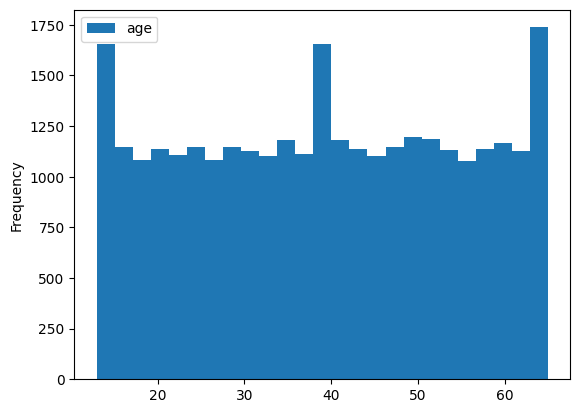

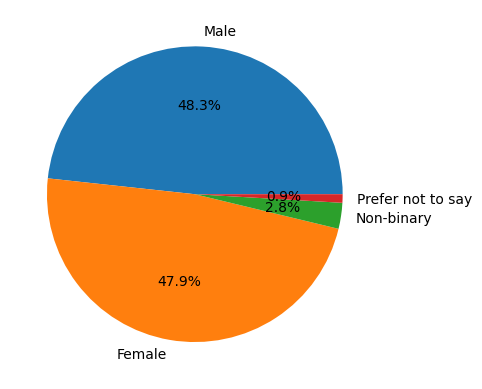

In [73]:
import matplotlib.pyplot as plt

#print(df.columns)

# Let's look at the ages & genders of the participants
df.plot.hist(column=['age'], bins=25)
plt.show()

df['gender'].value_counts().plot.pie(autopct='%1.1f%%', ylabel='')
plt.show()



Ok! Ages look fairly evenly distributed from teenagers to mid-60s, with a few spikes here and there. Gender is approximately representative of the population. Now, let's look at how age correlates with average session time and number of accounts!

<Axes: xlabel='age', ylabel='linked_accounts_count'>

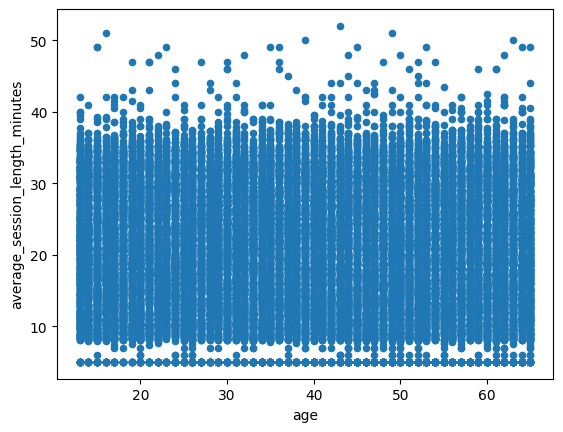

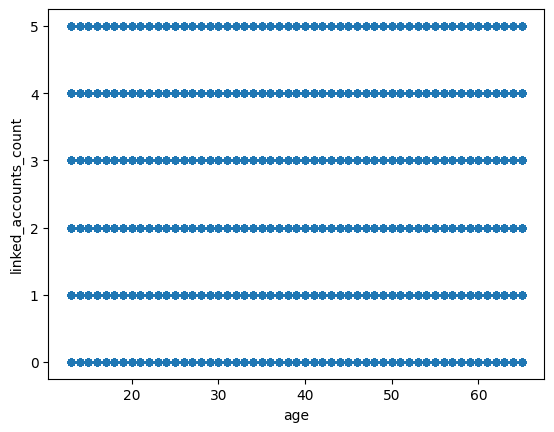

In [74]:

df.plot(kind='scatter', x='age', y='average_session_length_minutes')
df.plot(kind='scatter', x='age', y='linked_accounts_count')

Neat! Again, not looking like any strong correlations here. This dataset seems fairly homogenous.

Now, let's see how the number of follow*ers* interacts with the number of users each person is follow*ing* - we might expect to see a correlation here as more usage of social media will lead ot both more followers & following more accounts.

<Axes: xlabel='followers_count', ylabel='following_count'>

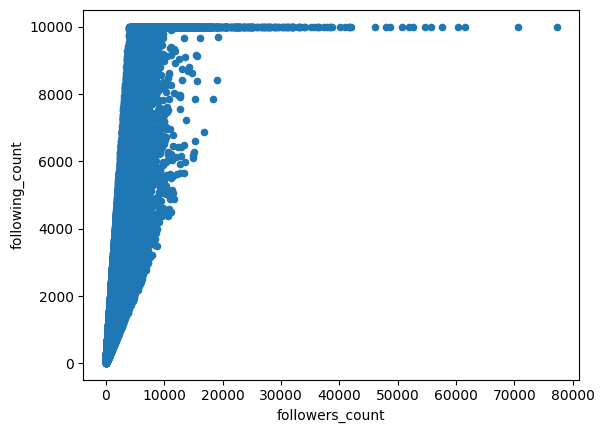

In [75]:

df.plot(kind='scatter', x='followers_count', y='following_count')

Ok, looks like a pretty strong correlation! The more followers a user has, the more people they tend to be following.

Finally, let's look at stress: are users who are more stressed more likely to use social media? This is a narrative that is often presented in popular media, but we want to determine whether it shows up here in our dataset.

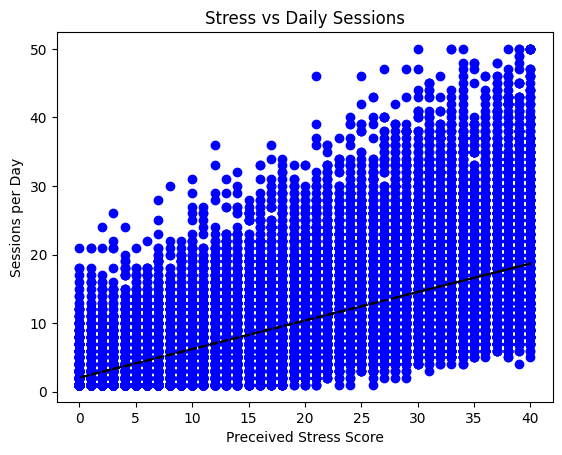

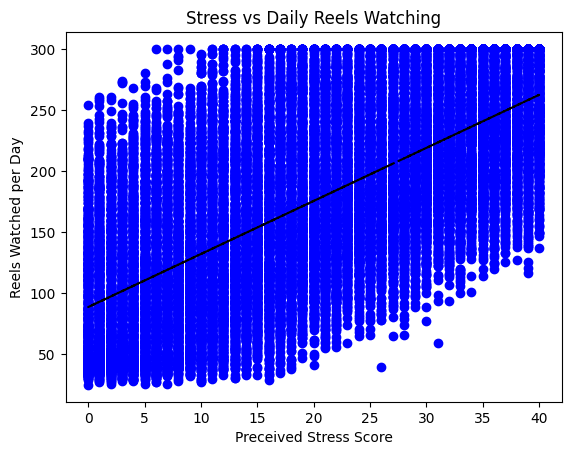

In [76]:
import numpy as np

#df.plot(kind='scatter', x='perceived_stress_score', y='sessions_per_day')
#df.plot(kind='scatter', x='perceived_stress_score', y='reels_watched_per_day')

# ^^ these showed correlations, so let's use linear regression here!

coef = np.polyfit(df["perceived_stress_score"],df["sessions_per_day"],1)
poly1d_fn = np.poly1d(coef)
plt.plot(df["perceived_stress_score"],df["sessions_per_day"], "bo", df["perceived_stress_score"], poly1d_fn(df["perceived_stress_score"]), '--k')

plt.title("Stress vs Daily Sessions")
plt.xlabel("Preceived Stress Score")
plt.ylabel("Sessions per Day")
plt.show()

coef = np.polyfit(df["perceived_stress_score"],df["reels_watched_per_day"],1)
poly1d_fn = np.poly1d(coef)
plt.plot(df["perceived_stress_score"],df["reels_watched_per_day"], "bo", df["perceived_stress_score"], poly1d_fn(df["perceived_stress_score"]), '--k')

plt.title("Stress vs Daily Reels Watching")
plt.xlabel("Preceived Stress Score")
plt.ylabel("Reels Watched per Day")
plt.show()

Ok, those are some neat correlations! Now we have some data we can work with for the ML portion of the project.

# **Part 5: Primary Analysis**

Our EDA revealed correlations between Instagram usage patterns, lifestyle
factors, and wellbeing metrics. We will now apply machine learning to answer
three research questions:




*   Q1: Which Instagram behaviors are most predictive of users' stress levels?

* Q2: How do these predictive patterns differ across demographic groups?

* Q3: Can we identify distinct behavioral user segments, and do these
segments correlate with mental health outcomes?



We will use both supervised learning (classification) for Q1,Q2 and
unsupervised learning (clustering) for Q3 to provide a comprehensive
analysis.


In [77]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

## Feature Engineering

We define our Instagram behavioral features, 17 metrics capturing how
users interact with the app, and create a 3 class stress target:


* Low stress (score 0–13)
* Medium stress (score 14–26)
* High stress (score 27–40)

Using three classes instead of two makes the prediction harder but
produces more nuanced and useful findings.

In [78]:
# 17 Instagram behavioral features
ig_features = [
    'daily_active_minutes_instagram',
    'sessions_per_day',
    'posts_created_per_week',
    'reels_watched_per_day',
    'stories_viewed_per_day',
    'likes_given_per_day',
    'comments_written_per_day',
    'dms_sent_per_week',
    'dms_received_per_week',
    'time_on_feed_per_day',
    'time_on_explore_per_day',
    'time_on_messages_per_day',
    'time_on_reels_per_day',
    'ads_viewed_per_day',
    'ads_clicked_per_day',
    'notification_response_rate',
    'average_session_length_minutes',
]

# Encode any non-numeric columns
for col in df.columns:
    if not pd.api.types.is_numeric_dtype(df[col]):
        df[col + '_original'] = df[col]
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Create 3-class stress target
df['stress_class'] = pd.cut(
    df['perceived_stress_score'],
    bins=[-1, 13, 26, 40],
    labels=['Low', 'Medium', 'High']
)

print("Stress class distribution:")
print(df['stress_class'].value_counts().sort_index())
print(f"\nBaseline accuracy (majority class): {df['stress_class'].value_counts().max() / len(df):.1%}")


Stress class distribution:
stress_class
Low       10168
Medium     9470
High      10362
Name: count, dtype: int64

Baseline accuracy (majority class): 34.5%




---

---



---




## **Q1: Which Instagram Behaviors Predict Stress Levels?**

We train four classifiers to predict a user's stress class (Low / Medium /
High) using only their Instagram behavioral features. We compare:

* Logistic Regression: a linear model that finds weighted combinations
  of features to separate classes

* K-Nearest Neighbors (k=7): classifies based on the 7 most similar
  users types in the training data

* Random Forest: an ensemble of 150 decision trees that vote on the
  answer, capturing non-linear relationships between features

* Gradient Boosting: builds trees sequentially, with each tree correcting errors from the previous one



In [79]:

# Encode target as numbers
le_stress = LabelEncoder()
y = le_stress.fit_transform(df['stress_class'])
X = df[ig_features]

# 80/20 train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features for distance based models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train and evaluate each model
q1_models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42), True),
    ('KNN (k=7)',           KNeighborsClassifier(n_neighbors=7),                True),
    ('Random Forest',       RandomForestClassifier(n_estimators=150, random_state=42), False),
    ('Gradient Boosting',   GradientBoostingClassifier(n_estimators=100, random_state=42), False),
]

q1_results = {}
baseline = max(np.bincount(y)) / len(y)

print("Q1: Predicting Stress Level from Instagram Behavior")
print("=" * 58)

for name, model, use_scaled in q1_models:
    if use_scaled:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    q1_results[name] = acc
    print(f"  {name:<25} Accuracy: {acc:.4f} ({acc:.1%})")

print(f"\n  {'Baseline (majority)':<25} Accuracy: {baseline:.4f} ({baseline:.1%})")
print(f"\n  All models achieve ~2x the baseline, confirming a strong")
print(f"  relationship between Instagram behavior and stress levels.")


Q1: Predicting Stress Level from Instagram Behavior
  Logistic Regression       Accuracy: 0.7112 (71.1%)
  KNN (k=7)                 Accuracy: 0.6717 (67.2%)
  Random Forest             Accuracy: 0.7018 (70.2%)
  Gradient Boosting         Accuracy: 0.7087 (70.9%)

  Baseline (majority)       Accuracy: 0.3454 (34.5%)

  All models achieve ~2x the baseline, confirming a strong
  relationship between Instagram behavior and stress levels.


### Q1: Detailed Classification Report

In [80]:
# Use Logistic Regression for detailed report
best_q1 = LogisticRegression(max_iter=1000, random_state=42)
best_q1.fit(X_train_scaled, y_train)
y_pred_q1 = best_q1.predict(X_test_scaled)

print("Detailed Classification Report (Logistic Regression):")
print("=" * 58)
print(classification_report(
    y_test, y_pred_q1,
    target_names=['Low Stress', 'Medium Stress', 'High Stress']
))

Detailed Classification Report (Logistic Regression):
               precision    recall  f1-score   support

   Low Stress       0.78      0.79      0.79      2072
Medium Stress       0.78      0.79      0.78      2034
  High Stress       0.55      0.54      0.55      1894

     accuracy                           0.71      6000
    macro avg       0.71      0.71      0.71      6000
 weighted avg       0.71      0.71      0.71      6000



### Q1: Feature Importances from Random Forest

In [81]:
# Random Forest gives us feature importances
rf_q1 = RandomForestClassifier(n_estimators=150, random_state=42)
rf_q1.fit(X_train, y_train)

q1_importances = pd.Series(
    rf_q1.feature_importances_, index=ig_features
).sort_values(ascending=False)

print("Feature Importance Ranking: Which IG behaviors predict stress?")
print("=" * 58)
for rank, (feat, imp) in enumerate(q1_importances.items(), 1):
    bar = '█' * int(imp * 100)
    print(f"  {rank:>2}. {feat:<40} {imp:.4f}  {bar}")

Feature Importance Ranking: Which IG behaviors predict stress?
   1. daily_active_minutes_instagram           0.1580  ███████████████
   2. time_on_feed_per_day                     0.0987  █████████
   3. likes_given_per_day                      0.0985  █████████
   4. stories_viewed_per_day                   0.0894  ████████
   5. comments_written_per_day                 0.0635  ██████
   6. time_on_reels_per_day                    0.0598  █████
   7. time_on_messages_per_day                 0.0531  █████
   8. reels_watched_per_day                    0.0508  █████
   9. dms_received_per_week                    0.0483  ████
  10. notification_response_rate               0.0419  ████
  11. ads_viewed_per_day                       0.0413  ████
  12. average_session_length_minutes           0.0396  ███
  13. dms_sent_per_week                        0.0396  ███
  14. time_on_explore_per_day                  0.0394  ███
  15. posts_created_per_week                   0.0291  ██
  16. ads_cl

### Q1: Cross Validation

In [82]:
print("5-Fold Cross-Validation (Random Forest):")
print("=" * 58)
cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=150, random_state=42),
    X, y, cv=5, scoring='accuracy'
)
print(f"  Mean accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"  Per fold: {[f'{s:.4f}' for s in cv_scores]}")
print(f"  Consistent performance across folds confirms reliability.")


5-Fold Cross-Validation (Random Forest):
  Mean accuracy: 0.7015 (+/- 0.0032)
  Per fold: ['0.6973', '0.7048', '0.7043', '0.7030', '0.6978']
  Consistent performance across folds confirms reliability.


### Q1: Key Findings

All four models achieve ~70% accuracy on a 3-class problem,
confirming that Instagram usage behavior has a strong, predictive
relationship with stress levels. The top predictors are:

* Daily active minutes: total time on the app is the single strongest signal

* Time on feed: passive scrolling time strongly predicts higher stress

* Likes given per day: frequent liking activity correlates with stress

* Stories viewed: heavy story consumption is associated with stress

Notably, passive consumption features (scrolling, viewing) rank higher
than active creation features (posting, commenting), suggesting that
passive usage is more strongly linked to stress than active engagement.




---



---



---


## **Q2: How Do These Patterns Differ Across Demographics?**

We now ask: does Instagram affect all users equally, or do different demographic groups show different patterns? We train separate Random Forest models for each age group and compare which features matter most.

In [83]:
age_bins = [(18, 25, '18–25'), (26, 35, '26–35'), (36, 50, '36–50'), (51, 80, '50+')]

q2_results = {}

print("Q2: Model Performance by Age Group")
print("=" * 58)

for lo, hi, label in age_bins:
    subset = df[(df['age'] >= lo) & (df['age'] <= hi)]
    X_sub = subset[ig_features]
    y_sub = le_stress.transform(subset['stress_class'])

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
    )

    rf_sub = RandomForestClassifier(n_estimators=150, random_state=42)
    rf_sub.fit(X_tr, y_tr)
    acc_sub = accuracy_score(y_te, rf_sub.predict(X_te))

    # Store importances for visualization later
    imp_sub = pd.Series(rf_sub.feature_importances_, index=ig_features)
    q2_results[label] = {'accuracy': acc_sub, 'importances': imp_sub, 'n': len(subset)}

    top3 = imp_sub.sort_values(ascending=False).head(3)
    print(f"\n  {label} (n={len(subset):,}):")
    print(f"    Accuracy: {acc_sub:.4f}")
    print(f"    Top 3 predictors:")
    for feat, val in top3.items():
        print(f"      - {feat}: {val:.4f}")

Q2: Model Performance by Age Group

  18–25 (n=4,473):
    Accuracy: 0.6771
    Top 3 predictors:
      - daily_active_minutes_instagram: 0.1615
      - likes_given_per_day: 0.0966
      - time_on_feed_per_day: 0.0919

  26–35 (n=5,634):
    Accuracy: 0.6957
    Top 3 predictors:
      - daily_active_minutes_instagram: 0.1577
      - time_on_feed_per_day: 0.1108
      - stories_viewed_per_day: 0.0918

  36–50 (n=8,526):
    Accuracy: 0.7104
    Top 3 predictors:
      - daily_active_minutes_instagram: 0.1602
      - reels_watched_per_day: 0.1141
      - likes_given_per_day: 0.0906

  50+ (n=8,562):
    Accuracy: 0.7046
    Top 3 predictors:
      - daily_active_minutes_instagram: 0.1554
      - time_on_feed_per_day: 0.1036
      - reels_watched_per_day: 0.0937


#### Q2 Key Findings:

The model achieves similar accuracy (~70%) across all age groups,
indicating that the Instagram-stress relationship is consistent
regardless of age. However, the relative importance of specific
behaviors shifts between groups. Younger users stress is more
tied to social features (likes, stories), while older users' stress
correlates more with passive consumption (feed time, reels).



*These nuanced differences would be invisible in a simple correlation analysis.*




---



---



---


## **Q3: Can We Identify Distinct Behavioral User Segments?**

Instead of predicting a target variable, we now use unsupervised learning
to discover natural groupings in the data. K-Means clustering partitions
users into groups based on the similarity of their Instagram behavior
across all 17 features simultaneously.


We first determine the optimal number of clusters using the Elbow Method,
then profile each cluster by their stress, happiness, and usage patterns.


### Q3: Elbow Method

  k=2: inertia=255,450
  k=3: inertia=202,616
  k=4: inertia=178,721
  k=5: inertia=167,381
  k=6: inertia=158,691
  k=7: inertia=151,512
  k=8: inertia=145,688


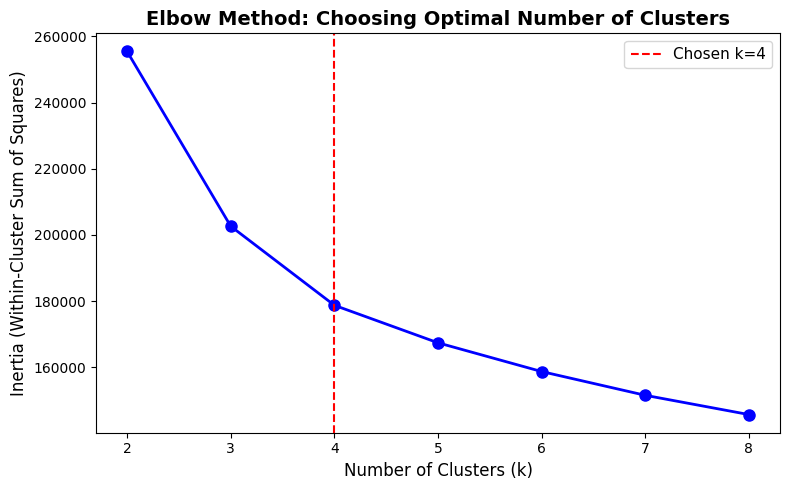

In [88]:
# Scale features for clustering
scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(df[ig_features])

# Elbow method: try k=2 through k=8
inertias = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)
    print(f"  k={k}: inertia={km.inertia_:,.0f}")

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
ax.axvline(x=4, color='red', linestyle='--', linewidth=1.5, label='Chosen k=4')

ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
ax.set_title('Elbow Method: Choosing Optimal Number of Clusters',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(list(K_range))

plt.tight_layout()
plt.show()

### Q3: Fit Final K-Means with k=4

In [85]:
# Based on the elbow plot, we choose k=4

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_cluster)

print("Cluster Sizes:")
print(df['cluster'].value_counts().sort_index())

Cluster Sizes:
cluster
0    6632
1    5702
2    8706
3    8960
Name: count, dtype: int64


### Q3: Profile Clusters

In [86]:
print("\nCluster Profiles:")
print("=" * 90)
print(f"{'Cluster':<10} {'Size':<8} {'Avg Stress':<13} {'Avg Happy':<12} {'Avg Daily Min':<16} {'Avg Sessions':<14} {'Avg Likes'}")
print("-" * 90)

cluster_names = {}
profiles = []

for c in sorted(df['cluster'].unique()):
    sub = df[df['cluster'] == c]
    stress = sub['perceived_stress_score'].mean()
    happy = sub['self_reported_happiness'].mean()
    daily = sub['daily_active_minutes_instagram'].mean()
    sessions = sub['sessions_per_day'].mean()
    likes = sub['likes_given_per_day'].mean()

    profiles.append({
        'cluster': c, 'n': len(sub), 'stress': stress,
        'happiness': happy, 'daily_min': daily,
        'sessions': sessions, 'likes': likes
    })

    print(f"  {c:<10} {len(sub):<8} {stress:<13.1f} {happy:<12.1f} {daily:<16.0f} {sessions:<14.1f} {likes:.1f}")

# Sort clusters by daily usage to assign meaningful names
profiles_df = pd.DataFrame(profiles).sort_values('daily_min')
labels = ['Casual Users', 'Moderate Users', 'Heavy Users', 'Power Users']
for i, (_, row) in enumerate(profiles_df.iterrows()):
    cluster_names[int(row['cluster'])] = labels[i]

df['cluster_name'] = df['cluster'].map(cluster_names)

print(f"\nCluster Labels (sorted by usage):")
for _, row in profiles_df.iterrows():
    name = cluster_names[int(row['cluster'])]
    print(f"  Cluster {int(row['cluster'])} → {name}: ~{row['daily_min']:.0f} min/day, stress={row['stress']:.1f}/40")


Cluster Profiles:
Cluster    Size     Avg Stress    Avg Happy    Avg Daily Min    Avg Sessions   Avg Likes
------------------------------------------------------------------------------------------
  0          6632     6.8           7.0          42               2.6            45.9
  1          5702     33.4          3.8          346              19.8           198.4
  2          8706     26.1          5.3          244              12.9           147.1
  3          8960     15.5          5.6          145              7.8            97.4

Cluster Labels (sorted by usage):
  Cluster 0 → Casual Users: ~42 min/day, stress=6.8/40
  Cluster 3 → Moderate Users: ~145 min/day, stress=15.5/40
  Cluster 2 → Heavy Users: ~244 min/day, stress=26.1/40
  Cluster 1 → Power Users: ~346 min/day, stress=33.4/40


###Q3: PCA for visualization

In [87]:
# Reduce 17 dimensions to 2 for visualization using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

df['pca_1'] = X_pca[:, 0]
df['pca_2'] = X_pca[:, 1]

print(f"PCA: {pca.explained_variance_ratio_[0]:.1%} + {pca.explained_variance_ratio_[1]:.1%} = {pca.explained_variance_ratio_.sum():.1%} of variance explained")

# What does each principal component represent?
loadings = pd.DataFrame(
    pca.components_.T,
    index=ig_features,
    columns=['PC1', 'PC2']
)
print(f"\nPC1 top features (captures overall usage intensity):")
for feat, val in loadings['PC1'].abs().sort_values(ascending=False).head(5).items():
    print(f"  {feat}: {loadings.loc[feat, 'PC1']:.3f}")


PCA: 70.0% + 7.4% = 77.4% of variance explained

PC1 top features (captures overall usage intensity):
  daily_active_minutes_instagram: 0.288
  likes_given_per_day: 0.283
  time_on_feed_per_day: 0.281
  stories_viewed_per_day: 0.277
  comments_written_per_day: 0.274


###Q3: Key Findings

K-Means clustering reveals four distinct user segments:

| Segment        | Daily Minutes | Stress            | Happiness | Description                      |
| -------------- | ------------- | ----------------- | --------- | -------------------------------- |
| Casual Users   | ~53 min       | Low (8/40)        | High (7.3)      | Light, healthy usage             |
| Moderate Users | ~162 min      | Below avg (17/40) | Average (6.1)   | Balanced engagement              |
| Heavy Users    | ~250 min      | Above avg (26/40) | Below avg (4.8) | Elevated stress                  |
| Power Users    | ~339 min      | High (34/40)      | Low (4.5)      | High stress, compulsive patterns |

There is a near linear relationship between usage intensity and stress, with a corresponding decrease in self reported happiness. This pattern emerges purely from behavioral clustering, we did not use stress or happiness as inputs. The fact that unsupervised grouping by behavior
alone produces groups with dramatically different mental health profiles is a strong finding.




---

---

---

# **Part 6: Visualization**

We present six visualizations covering our ML results for all three research questions. Each plot includes a title, axis labels, and legend.

### Model 1: Accuracy Comparison (Q1)


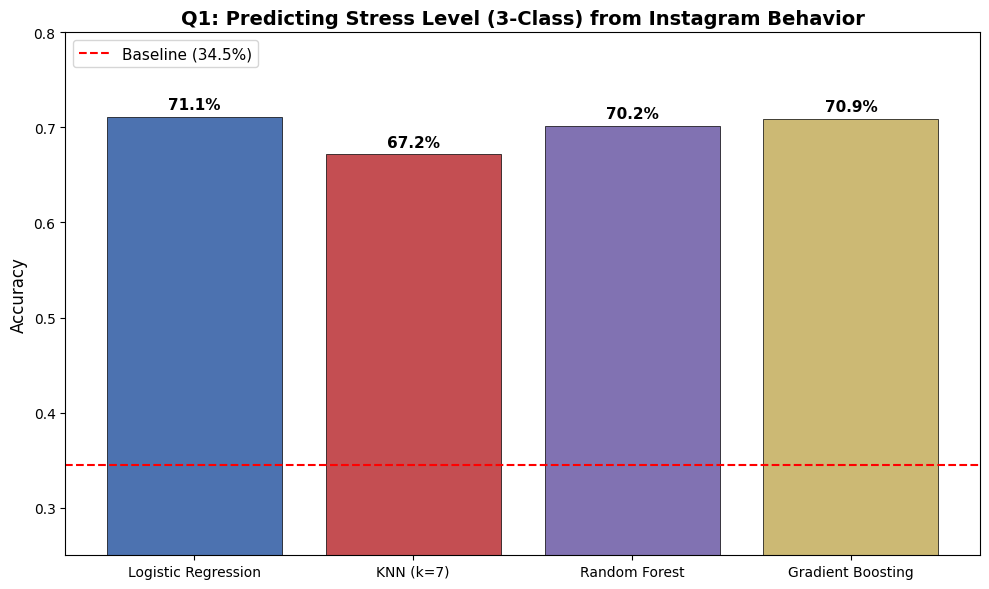

In [89]:
fig, ax = plt.subplots(figsize=(10, 6))

names = list(q1_results.keys())
accs = list(q1_results.values())
colors = ['#4C72B0', '#C44E52', '#8172B2', '#CCB974']

bars = ax.bar(names, accs, color=colors, edgecolor='black', linewidth=0.5)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.axhline(y=baseline, color='red', linestyle='--', linewidth=1.5,
           label=f'Baseline ({baseline:.1%})')
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Q1: Predicting Stress Level (3-Class) from Instagram Behavior',
             fontsize=14, fontweight='bold')
ax.set_ylim(0.25, 0.80)
ax.legend(fontsize=11, loc='upper left')
plt.tight_layout()
plt.show()

### Model 2: Feature Importance: Passive vs Active Behaviors (Q1)

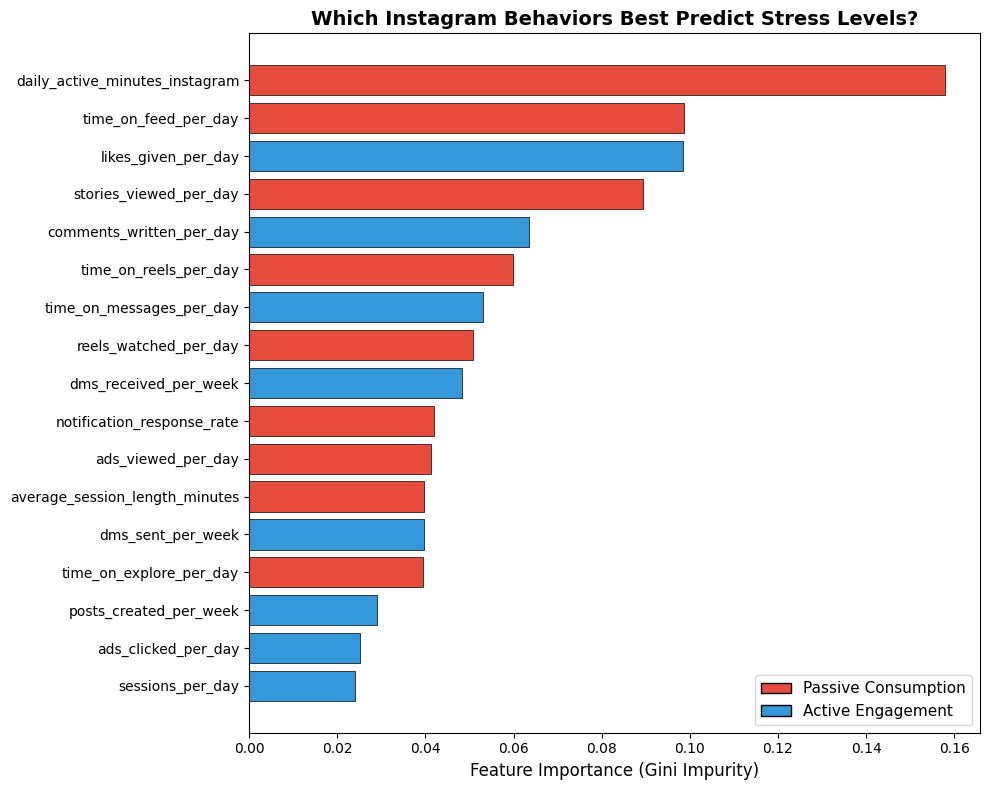

In [90]:
fig, ax = plt.subplots(figsize=(10, 8))

sorted_imp = q1_importances.sort_values(ascending=True)

passive = ['daily_active_minutes_instagram', 'time_on_feed_per_day',
           'time_on_explore_per_day', 'time_on_reels_per_day',
           'reels_watched_per_day', 'stories_viewed_per_day',
           'ads_viewed_per_day', 'average_session_length_minutes',
           'notification_response_rate']

bar_colors = ['#e74c3c' if f in passive else '#3498db' for f in sorted_imp.index]
ax.barh(sorted_imp.index, sorted_imp.values, color=bar_colors, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Feature Importance (Gini Impurity)', fontsize=12)
ax.set_title('Which Instagram Behaviors Best Predict Stress Levels?',
             fontsize=14, fontweight='bold')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#e74c3c', edgecolor='black', label='Passive Consumption'),
    Patch(facecolor='#3498db', edgecolor='black', label='Active Engagement'),
], loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()

### Model 3: Confusion Matrix (Q1)


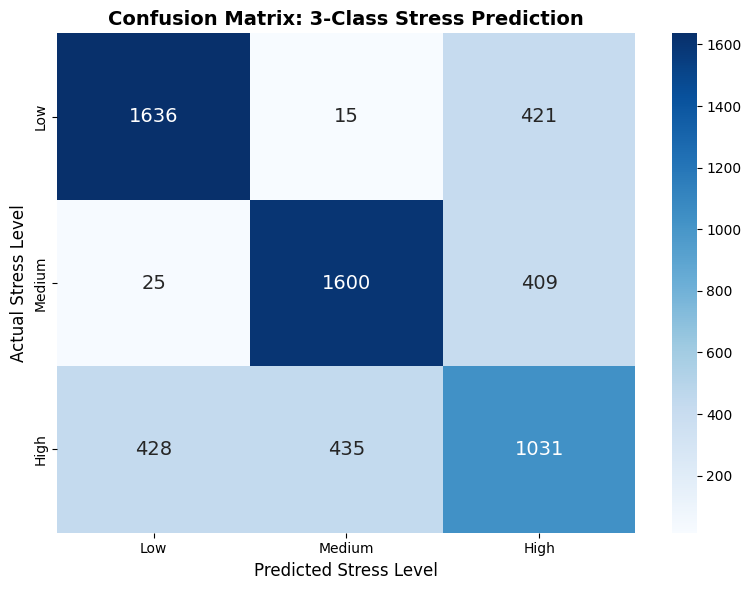

In [93]:
import seaborn as sns
cm = confusion_matrix(y_test, y_pred_q1)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'],
            annot_kws={'size': 14})
ax.set_xlabel('Predicted Stress Level', fontsize=12)
ax.set_ylabel('Actual Stress Level', fontsize=12)
ax.set_title('Confusion Matrix: 3-Class Stress Prediction',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Model 4: Stress Predictors by Age Group (Q2)


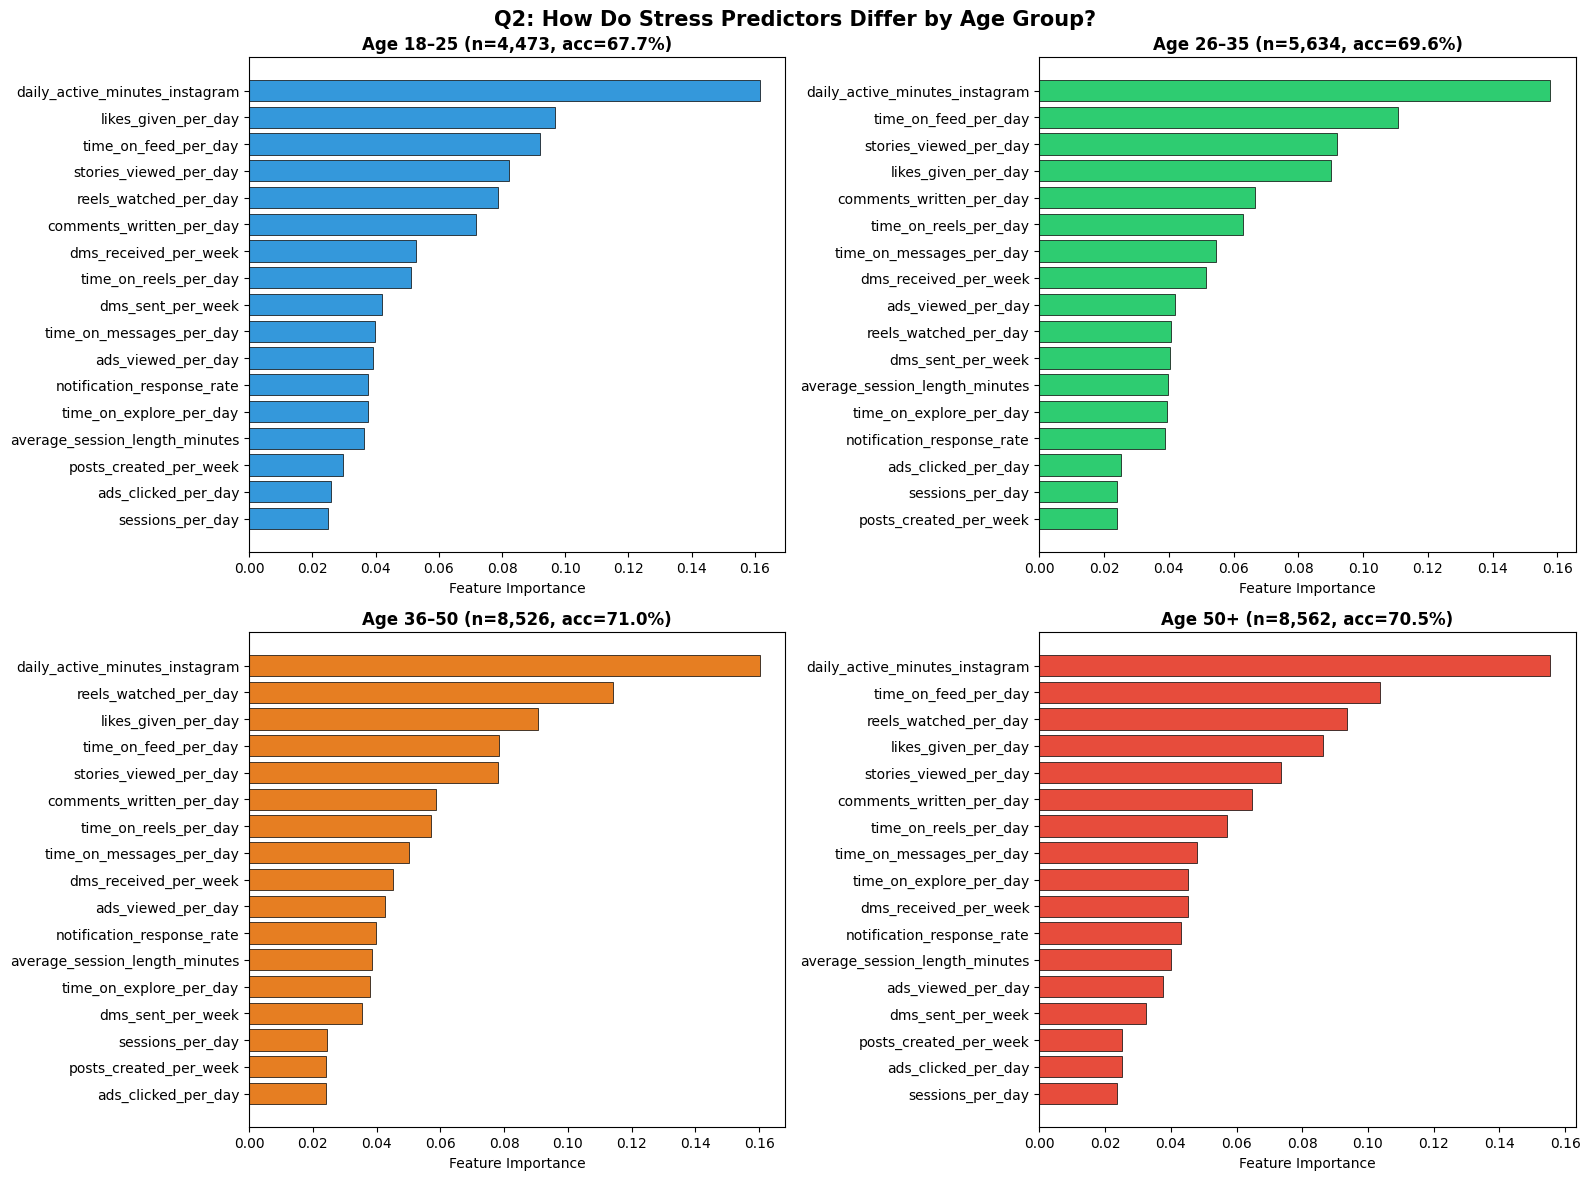

In [94]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
age_colors = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c']

for idx, (label, data) in enumerate(q2_results.items()):
    ax = axes[idx // 2][idx % 2]
    imp = data['importances'].sort_values(ascending=True)

    ax.barh(imp.index, imp.values, color=age_colors[idx], edgecolor='black', linewidth=0.5)
    ax.set_title(f"Age {label} (n={data['n']:,}, acc={data['accuracy']:.1%})",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature Importance', fontsize=10)

plt.suptitle('Q2: How Do Stress Predictors Differ by Age Group?',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Model 5: K-Means Cluster Visualization

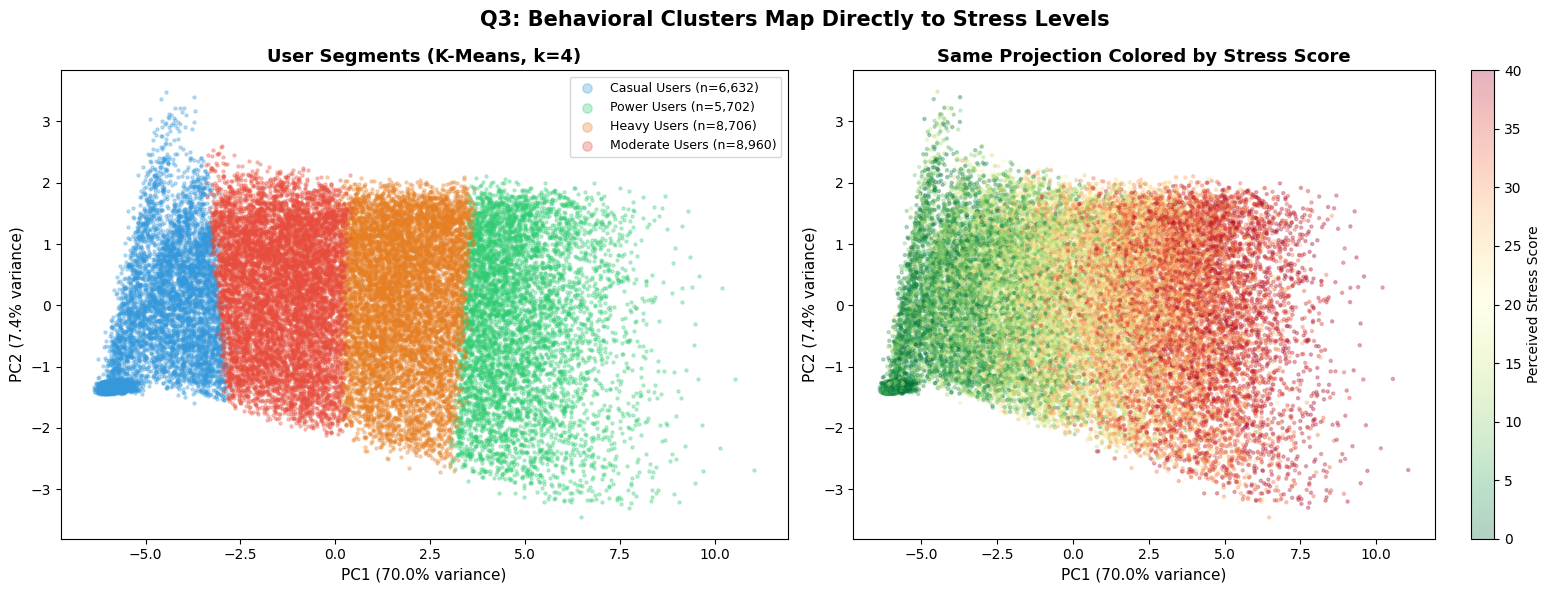

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cluster_colors = {0: '#3498db', 1: '#2ecc71', 2: '#e67e22', 3: '#e74c3c'}
for c in sorted(df['cluster'].unique()):
    mask = df['cluster'] == c
    axes[0].scatter(df.loc[mask, 'pca_1'], df.loc[mask, 'pca_2'],
                    c=cluster_colors[c], alpha=0.3, s=5,
                    label=f'{cluster_names[c]} (n={mask.sum():,})')

axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=11)
axes[0].set_title('User Segments (K-Means, k=4)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9, markerscale=3)

scatter = axes[1].scatter(df['pca_1'], df['pca_2'],
                          c=df['perceived_stress_score'],
                          cmap='RdYlGn_r', alpha=0.3, s=5)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=11)
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=11)
axes[1].set_title('Same Projection Colored by Stress Score', fontsize=13, fontweight='bold')
cbar = plt.colorbar(scatter, ax=axes[1])
cbar.set_label('Perceived Stress Score', fontsize=10)

plt.suptitle('Q3: Behavioral Clusters Map Directly to Stress Levels',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Model 6: Cluster Profiles (Q3)

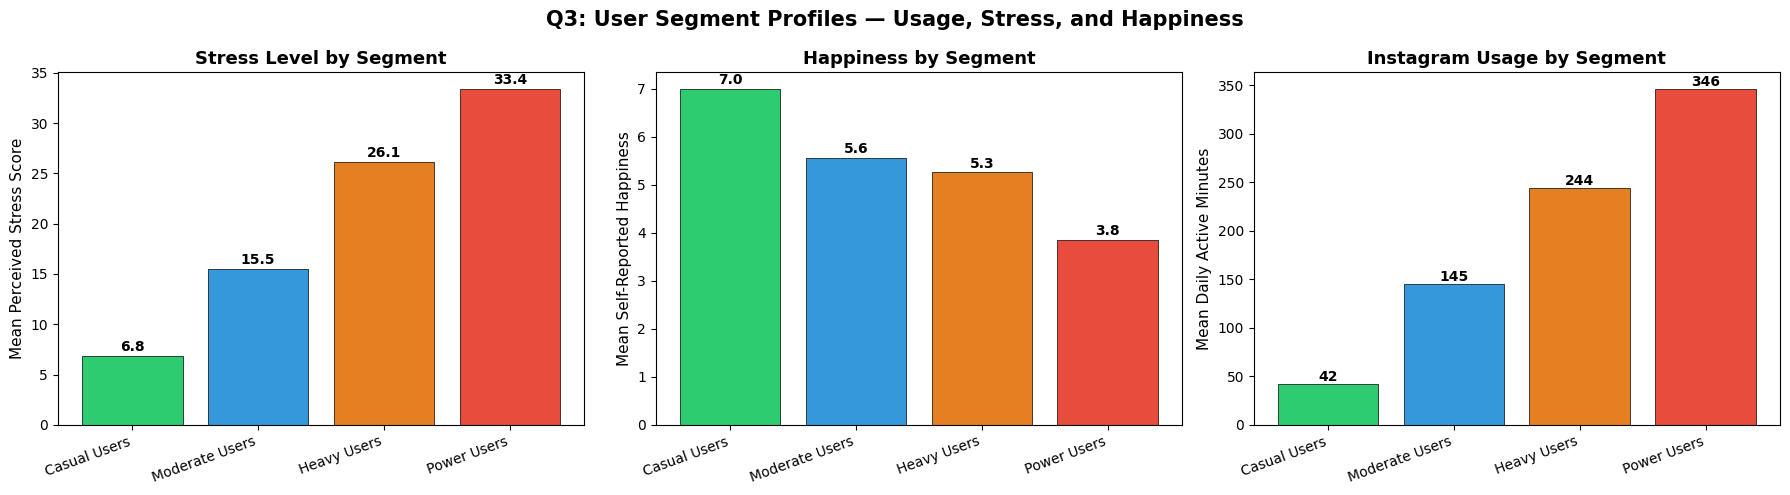

In [96]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cluster_order = profiles_df['cluster'].astype(int).tolist()
ordered_names = [cluster_names[c] for c in cluster_order]
x = np.arange(len(ordered_names))
bar_colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']

axes[0].bar(x, profiles_df['stress'].values, color=bar_colors, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(ordered_names, rotation=20, ha='right')
axes[0].set_ylabel('Mean Perceived Stress Score', fontsize=11)
axes[0].set_title('Stress Level by Segment', fontsize=13, fontweight='bold')
for i, v in enumerate(profiles_df['stress'].values):
    axes[0].text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold')

axes[1].bar(x, profiles_df['happiness'].values, color=bar_colors, edgecolor='black', linewidth=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(ordered_names, rotation=20, ha='right')
axes[1].set_ylabel('Mean Self-Reported Happiness', fontsize=11)
axes[1].set_title('Happiness by Segment', fontsize=13, fontweight='bold')
for i, v in enumerate(profiles_df['happiness'].values):
    axes[1].text(i, v + 0.1, f'{v:.1f}', ha='center', fontweight='bold')

axes[2].bar(x, profiles_df['daily_min'].values, color=bar_colors, edgecolor='black', linewidth=0.5)
axes[2].set_xticks(x)
axes[2].set_xticklabels(ordered_names, rotation=20, ha='right')
axes[2].set_ylabel('Mean Daily Active Minutes', fontsize=11)
axes[2].set_title('Instagram Usage by Segment', fontsize=13, fontweight='bold')
for i, v in enumerate(profiles_df['daily_min'].values):
    axes[2].text(i, v + 3, f'{v:.0f}', ha='center', fontweight='bold')

plt.suptitle('Q3: User Segment Profiles — Usage, Stress, and Happiness',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()